<a href="https://colab.research.google.com/github/qgelena/US-_monthly-_electricity_generation/blob/main/ftse_assignment_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentals of Time Series Econometrics

## Assignment: Modelling US National Electricity Generation

This notebook is a part of the course *"Fundamentals of Time Series Econometrics"* by VU Amsterdam in the minor *"Applied Econometrics: A Big Data Experience for all"*. This notebook contains the assignment for this course and will cover modelling national electricity generation in the US.

### Data
The data describe the US monthly electricity generation from January 1973 to May 2026. More specifically, they pertain to total net generation across all sectors (MSN: ELETPUS). The data come from the U.S. Energy Information Administration ([source](https://www.eia.gov/totalenergy/data/browser/csv.php?tbl=T07.01)).  The series is provided in the `MER_T07_01.csv` file, which can be found in the *Data* module on Canvas.


### Structure
In total, you can get 100 points for the assignment. The assignment consists of five main parts. The parts and the point distribution are specified below.

* Part 1: Preparation (25 pts)
* Part 2: Baseline Model (15 pts)
* Part 3: Model Selection In-Sample (15 pts)
* Part 4: Model Selection Out-of-Sample (20 pts)
* Part 5: Benchmarking (25 pts)

In [2]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.tsa.api as tsa
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
import os
import pandas as pd
import seaborn as sns

drive.mount('/content/drive')

base_dir = '/content/drive/My Drive/code/'
data_dir = base_dir + 'data/'
figs_dir = base_dir + 'figs/'
dpi = 150

os.makedirs(figs_dir, exist_ok=True)

# US national electricity generation
electricity = pd.read_csv(data_dir + 'MER_T07_01.csv', header=0)

Mounted at /content/drive


# PART 1: Preparation (25 pts)

## 1. Load and visualize the US national electricity generation time series

In the cell below you are expected to load the US national electricity generation time series. The data are stored in the file `MER_T07_01.csv`. The file contains multiple columns of which `YYYYMM` and `Value` are important. The `YYYYMM` column contains the date value in a YYYYMM format value (e.g. 200001 for January 2000), and the `Value` column contains the US national electricity generation (in thousand Megawatthours). **Note:** In the csv file there are entries coded as month 13. These are annual totals which you need to exclude.

After loading the data, you should visualize the time series. The time series should be plotted with the dates in the form of years on the x-axis and the  electricity generation series on the y-axis.

Comment on the dynamics of the time series. What do you observe? Do you believe the time series is stationary and why?

In [4]:
electricity.head(50)

,MSN,YYYYMM,Value,Column_Order,Description,Unit
0,ELEGPUS,194913,291.1,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
1,ELEGPUS,195013,329.141,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
2,ELEGPUS,195113,370.673,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
3,ELEGPUS,195213,399.224,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
4,ELEGPUS,195313,442.665,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
5,ELEGPUS,195413,471.686,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
6,ELEGPUS,195513,547.038,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
7,ELEGPUS,195613,600.668,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
8,ELEGPUS,195713,631.517,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours
9,ELEGPUS,195813,645.098,1,"Electricity Net Generation, Electric Power Sector",Billion Kilowatthours


In [5]:
print(electricity['MSN'].unique())
print(electricity.index.duplicated().sum())

['ELEGPUS' 'ELC5PUS' 'ELI5PUS' 'ELETPUS' 'ELIMPUS' 'ELEXPUS' 'ELNIPUS'
 'ELUNPUS' 'ESTCPUS' 'ELDUPUS' 'ELTCPUS']
0


In [6]:
electricity_ELETPUS =electricity[electricity["MSN"] == "ELETPUS"].copy()


electricity_ELETPUS = electricity_ELETPUS[electricity_ELETPUS['YYYYMM'] % 100 != 13]
electricity_ELETPUS['date'] = pd.to_datetime(electricity_ELETPUS['YYYYMM'].astype(str), format='%Y%m')
electricity_ELETPUS['Value'] = pd.to_numeric(electricity_ELETPUS['Value'], errors='coerce')
electricity_ELETPUS.set_index('date', inplace=True)

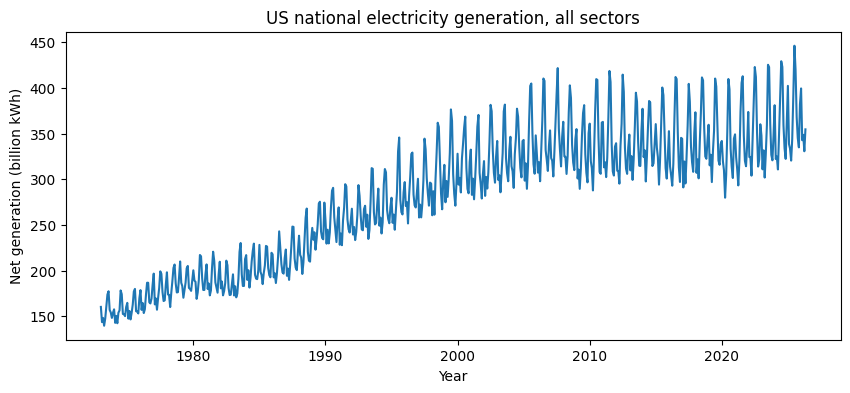

In [7]:
# plot
y= electricity_ELETPUS['Value'].sort_index().dropna()
y=y.asfreq("MS")

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(y.index, y.values)
ax.set_xlabel("Year")
ax.set_ylabel("Net generation (billion kWh)")
ax.set_title("US national electricity generation, all sectors")
plt.show()

The plot shows a clear upward trend: electricity generation in the US grows from about 150 billion kWh in 1973 to about 350 around 2007, followed by a plateau with a slight upward drift at the end. There is also regular yearly seasonality, with summer peaks (likely air conditioning demand), and the seasonal amplitude grows with the level (roughly 140-180 in the 1970s versus 290-420 in the 2010s). Small dips around 2009 and 2020 are likely due to the recession and COVID-19.

A weakly stationary series fluctuates around a fixed level and returns to it after deviations.

Formally:

1. constant mean, E[X_t] = μ;
2. constant variance, Var(X_t) = σ²;
3. autocovariance depends only on the lag h, Cov(X_t, X_{t+h}) = γ(h).

I do not believe the series is stationary. (1) The mean is not constant: it rises over decades (trend) and depends on the month (seasonality). (2) The variance is not constant: seasonal swings are larger in later years. (3) Because the mean changes over time, the autocovariance depends on t and not only on h, and we expect very slowly decaying autocorrelations.

## 2. Autocorrelation and Partial Autocorrelation

To gain a better understanding of the dynamics in US national electricity generation time series you are asked to plot the autocorrelation function (ACF) and partial autocorrelation function (PACF) of the time series in the cell below. You can set the amount of lags equal to 36 (equivalent to 3 years).

What do you observe in the ACF and PACF plots? What data transformations would you apply to the time series? What kind of dynamics are present in the time series?

Do you see any seasonal patterns in the ACF and PACF plots? Is this in line with what you observed in the time series plot? If there is a discrepancy, what does this tell you about the dynamics?

**ACF at lag h:** the correlation between the series today and h months ago.

**PACF at lag h:** the same correlation after removing the effect of the lags in between. It tells what lag h adds beyond lags 1 to h-1.

For a stationary series the ACF dies out quickly. For a trending series, the value today is close to the value last month, and the month before that, and so on, so the ACF stays high for a very long time.

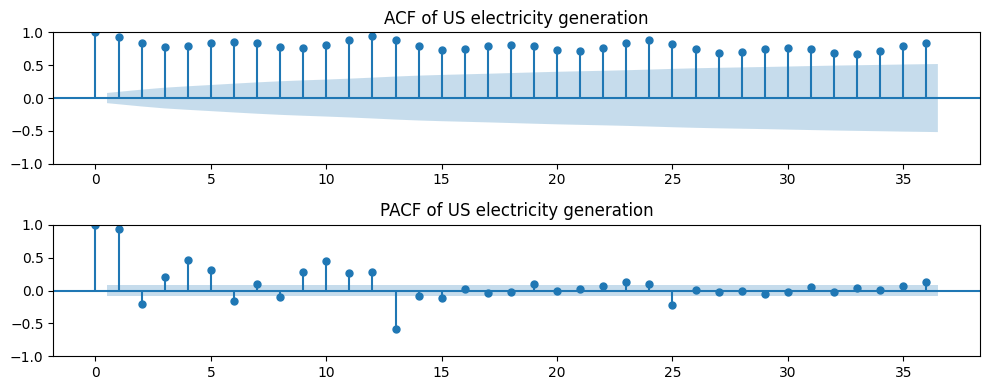

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2,1, figsize=(10,4))
plot_acf(y, lags=36, ax=axes[0])
plot_pacf(y, lags=36, ax=axes[1], method='ywm')
axes[0].set_title("ACF of US electricity generation")
axes[1].set_title("PACF of US electricity generation")
plt.tight_layout()
plt.show()

In [9]:
from statsmodels.tsa.stattools import acf, pacf

acf_vals = acf(y, nlags=36)
pacf_vals = pacf(y, nlags=36, method='ywm')

# confidence band (approx. 95%): +/- 1.96 / sqrt(n)
band = 1.96 / np.sqrt(len(y))

table = pd.DataFrame({'ACF': acf_vals, 'PACF': pacf_vals})
table['PACF significant'] = table['PACF'].abs() > band
print(table.round(3))
print("band:", round(band, 3))

# only the significant PACF lags
print(table[table['PACF significant']].index.tolist())

      ACF   PACF  PACF significant
0   1.000  1.000              True
1   0.931  0.931              True
2   0.839 -0.200              True
3   0.778  0.207              True
4   0.788  0.464              True
5   0.842  0.309              True
6   0.858 -0.166              True
7   0.835  0.104              True
8   0.775 -0.099              True
9   0.757  0.278              True
10  0.810  0.443              True
11  0.888  0.270              True
12  0.942  0.275              True
13  0.879 -0.586              True
14  0.791 -0.083              True
15  0.731 -0.111              True
16  0.742  0.028             False
17  0.795 -0.030             False
18  0.810 -0.026             False
19  0.788  0.098              True
20  0.729 -0.007             False
21  0.710  0.020             False
22  0.761  0.062             False
23  0.838  0.134              True
24  0.889  0.100              True
25  0.829 -0.224              True
26  0.744  0.004             False
27  0.686 -0.025    

The ACF decays extremely slowly: it stays between 0.67 and 0.94 across all 36 lags, far above the confidence bounds, and the PACF has a spike of 0.93 at lag 1. This is the signature of a non-stationary, highly persistent series with a trend (unit-root type behaviour). The ACF also has a regular wave with peaks at lags 12, 24 and 36 (0.94, 0.89, 0.84), and the PACF is significant at nearly all of lags 1 to 15 and again around lags 23 to 25 (notably -0.59 at lag 13), which indicates yearly seasonality (period 12).

**Transformations**: I would take logs to stabilise the seasonal amplitude, which grows with the level. I would also apply first differences to remove the trend, and a seasonal difference at lag 12 to remove the yearly pattern. Whether both differences are needed will follow from the stationarity tests.

**Dynamics present:** trend, strong persistence, and yearly seasonality.

**Discrepancy:** the seasonality is very clear in the time series plot but much less visible in the ACF, where it appears only as ripples on top of the slow decay. The trend dominates the autocorrelations and masks the seasonal pattern, so the seasonal structure can only be judged properly after the trend is removed.

## 3. Stationarity of the Time Series

Above you were asked to eyeball the data and form an opinion on the possibility for the time series to be stationary. We can use a statistical test to formalize this, such as the **ADF and KPSS tests.** In the cell below you are expected to test the stationarity of the time series using the ADF and KPSS tests. Note that the deterministic components alter the test hypothesis.

What do you conclude from the ADF and KPSS tests? Is the time series stationary? What are the implications for the modeling of the time series? Explain your reasoning for the chosen specification of the tests.

In [10]:
from statsmodels.tsa.stattools import adfuller, kpss

def run_tests(series, reg):
    adf= adfuller(series, regression=reg, autolag="AIC")
    kpss_test= kpss(series, regression=reg, nlags="auto")
    print(f"---regression ='{reg}' ---")

    print(f"ADF : stat = {adf[0]:.3f}, p = {adf[1]:.4f}, lags used = {adf[2]}, 5% crit = {adf[4]['5%']:.3f}")
    print(f"KPSS: stat = {kpss_test[0]:.3f}, p = {kpss_test[1]:.4f}, lags = {kpss_test[2]}, 5% crit = {kpss_test[3]['5%']:.3f}")

import warnings
warnings.filterwarnings("ignore")   # silences the Future/Interpolation warnings


run_tests(y, 'ct') #main specification
run_tests(y, 'c') #robustness check

---regression ='ct' ---
ADF : stat = -1.259, p = 0.8978, lags used = 14, 5% crit = -3.418
KPSS: stat = 1.348, p = 0.0100, lags = 9, 5% crit = 0.146
---regression ='c' ---
ADF : stat = -1.542, p = 0.5129, lags used = 14, 5% crit = -2.866
KPSS: stat = 3.652, p = 0.0100, lags = 16, 5% crit = 0.463


**YOUR ANSWER HERE**

## 4. Transform the Time Series

Given the result from the stationarity tests and the visual inspection of the time series, we might need to transform the time series to make it stationary. In the cell below, you are expected to transform the time series to make it stationary. Once you have transformed the time series, visualize the transformed time series.

Do you believe the transformed time series is stationary?

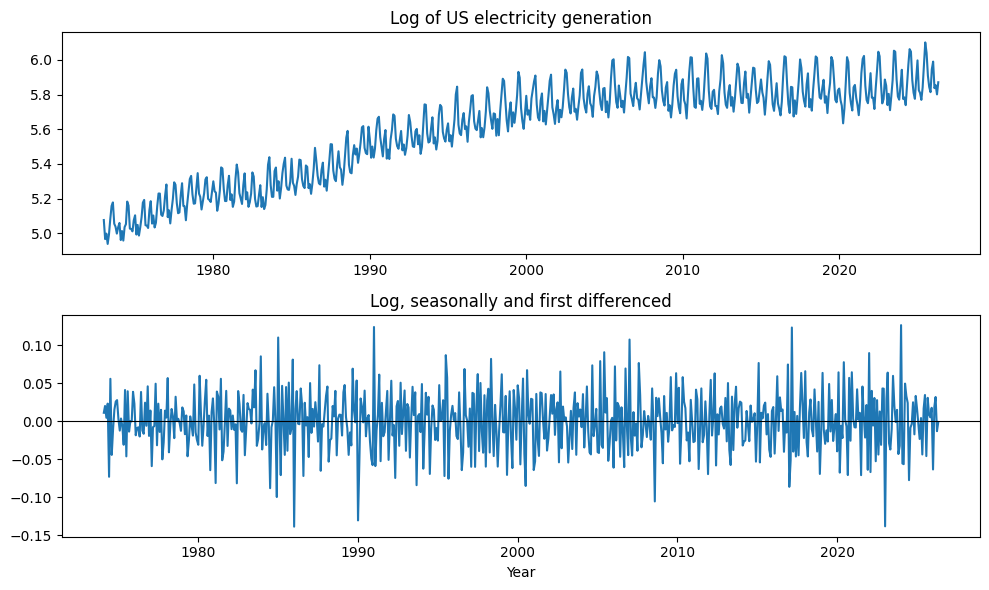

628 1974-02-01 00:00:00


In [11]:
log_y = np.log(y)

# seasonal difference first, then ordinary difference
z = log_y.diff(12).diff(1).dropna()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
axes[0].plot(log_y.index, log_y.values)
axes[0].set_title("Log of US electricity generation")
axes[1].plot(z.index, z.values)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title("Log, seasonally and first differenced")
axes[1].set_xlabel("Year")
plt.tight_layout()
plt.show()

print(len(z), z.index[0])   # lost 13 observations: 641 - 13 = 628, starts Feb 1974

The ADF/KPSS tests show the series is non-stationary, and the ACF shows both trend and yearly seasonality. I apply (1) a log transform to stabilise the growing seasonal amplitude, (2) a seasonal difference at lag 12 to remove the yearly pattern, and (3) a first difference to remove the stochastic trend, giving $z_t = \Delta\Delta_{12}\ln X_t$. The transformed series fluctuates around zero without trend or seasonality and with roughly constant variance, so I believe it is stationary. I verify this formally in question 5.

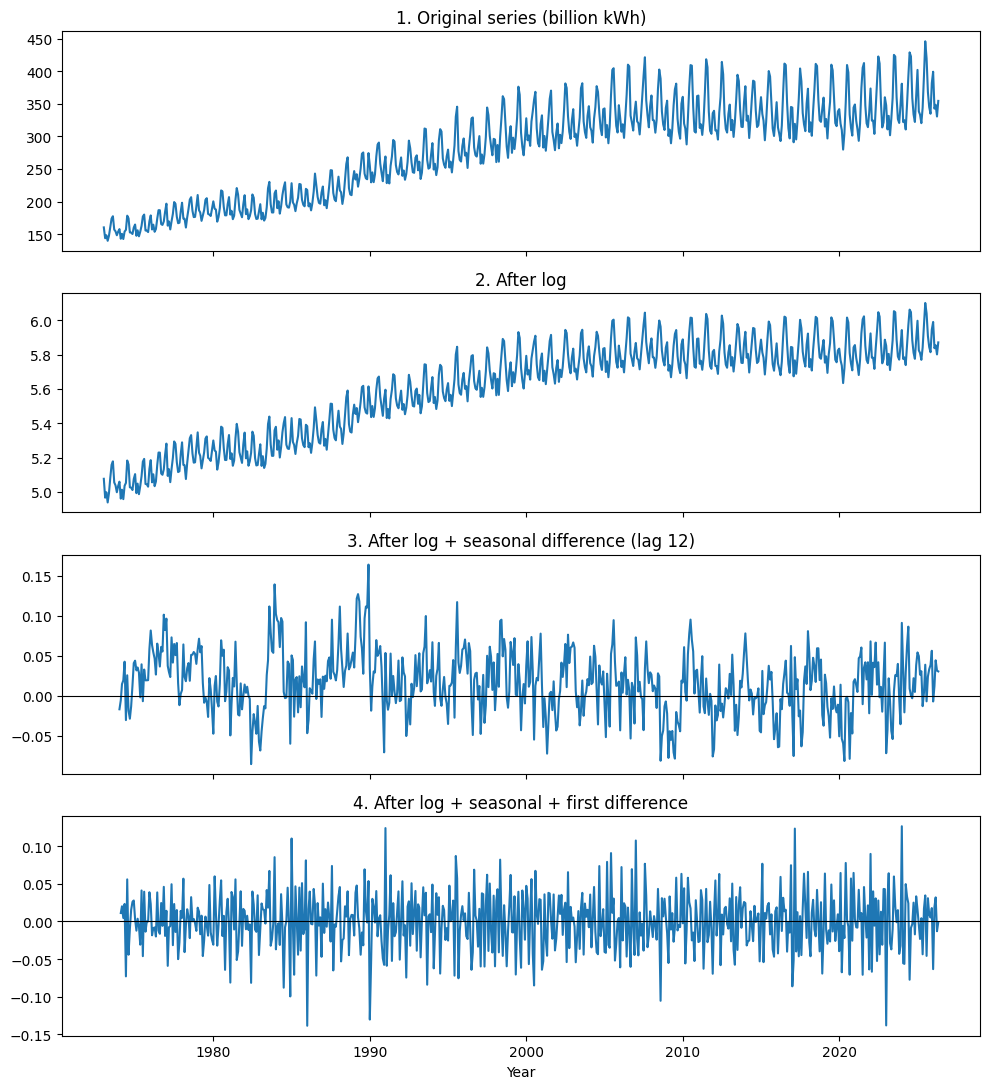

In [12]:
log_y   = np.log(y)
seas_d  = log_y.diff(12).dropna()          # after seasonal difference
z       = log_y.diff(12).diff(1).dropna()  # after seasonal + first difference

stages = [
    (y,      "1. Original series (billion kWh)"),
    (log_y,  "2. After log"),
    (seas_d, "3. After log + seasonal difference (lag 12)"),
    (z,      "4. After log + seasonal + first difference"),
]

fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
for ax, (s, title) in zip(axes, stages):
    ax.plot(s.index, s.values)
    ax.set_title(title)
    if s is seas_d or s is z:
        ax.axhline(0, color='black', linewidth=0.8)
axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.savefig(figs_dir + 'transformation_stages.png', dpi=dpi)
plt.show()

The tests in question 3 and the ACF in question 2 show that the series has a stochastic trend, yearly seasonality, and seasonal swings that grow with the level. I therefore transform the series in three steps, shown in the figure.

**Log transform.** The seasonal amplitude in the original series grows over time. After taking logs the seasonal swings have roughly the same size throughout the sample, so the variance is stabilised.

**Seasonal difference ($s = 12$).** Computing $\ln X_t - \ln X_{t-12}$ compares each month with the same month a year earlier and removes the regular yearly pattern. The series still moves slowly over time (it is higher in the 1970s and 1980s, when growth was fast), so it is not yet centred on a fixed level.

**First difference.** Computing $\Delta$ of the seasonally differenced series removes this remaining slow-moving trend component.

The final transformed series is

$$z_t = \Delta\Delta_{12}\ln X_t = (\ln X_t - \ln X_{t-1}) - (\ln X_{t-12} - \ln X_{t-13}).$$

Is it stationary? I believe so. The series fluctuates around zero, shows no trend and no visible yearly pattern, and its spread looks roughly constant over time. There are a few larger outliers (around $\pm 0.12$ to $\pm 0.14$, e.g. in the mid-1980s, 1990-91 and 2023), but they do not change the overall level or variance. I confirm this formally with ADF and KPSS tests in question 5. The transformation costs 13 observations (12 for the seasonal difference and 1 for the first difference), so the sample starts in February 1974.

## 5. Validate the Stationarity of the Transformed Time Series
In the cell below you are expected to validate the stationarity of the transformed time series using the ADF and KPSS tests. What do you conclude from the ADF and KPSS tests? Is the transformed time series stationary? Explain your reasoning for the chosen specification of the tests.

In [19]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

def run_tests(series, reg):
    adf = adfuller(series, regression=reg, autolag="AIC")
    kpss_test = kpss(series, regression= reg, nlags= "auto")
    print(f"---regression = '{reg}' ---")
    print(f"ADF : stat = {adf[0]:.3f}, p = {adf[1]:.4f}, lags used = {adf[2]}, 5% crit = {adf[4]['5%']:.3f}")
    print(f"KPSS: stat = {kpss_test[0]:.3f},  p = {kpss_test[1]:.4f}, lags = {kpss_test[2]}, 5% crit = {kpss_test[3]['5%']:.3f}")

run_tests(z, 'ct') #robustness check
run_tests(z, 'c') #main specification

---regression = 'ct' ---
ADF : stat = -9.505, p = 0.0000, lags used = 18, 5% crit = -3.418
KPSS: stat = 0.046,  p = 0.1000, lags = 45, 5% crit = 0.146
---regression = 'c' ---
ADF : stat = -9.512, p = 0.0000, lags used = 18, 5% crit = -2.866
KPSS: stat = 0.048,  p = 0.1000, lags = 45, 5% crit = 0.463


**Specification.**

After the log, seasonal and first differences, the series fluctuates around a fixed level near zero with no visible trend. My main specification therefore includes only a constant ('c'), so that the alternative hypothesis is stationarity around a constant mean. Including a trend term would test for a deterministic trend that the plot does not show. As a robustness check I also use a constant and trend ('ct'). ADF lag length is chosen by AIC (18 lags) and the KPSS bandwidth automatically.

**Results.**

The ADF test (H0: unit root) gives a statistic of $-9.51$ with a 5% critical value of $-2.87$ ($p < 0.01$), so the unit root is rejected. The KPSS test (H0: stationarity) gives $0.048$ with a 5% critical value of $0.463$ ($p \ge 0.10$), so stationarity is not rejected. The results are the same with a trend ($-9.51$ vs $-3.42$; $0.046$ vs $0.146$).

**Conclusion.**

Both tests, whose null hypotheses are opposite, agree that the transformed series is stationary. This contrasts with the original series, where ADF failed to reject the unit root and KPSS rejected stationarity. The transformation has therefore achieved its purpose, and the series can be modelled with a stationary seasonal ARMA, i.e. a SARIMA model with $d = 1$, $D = 1$ and $s = 12$.

# PART 2: Baseline Model (15 pts)

## 6. Model Structure

You are asked to plot the autocorrelation function (ACF) and partial autocorrelation function (PACF) of the transformed time series in the cell below. You can set the amount of lags equal 36 (equivalent to 3 years).

What do you observe in the ACF and PACF plots? What kind of dynamics are present in the time series? What kind of model structure would you propose for the time series? Explain your reasoning.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

## 7. Model Estimation

In the cell below you are expected to estimate the model structure you proposed in the previous question. You can use the `ARIMA` and/or `SARIMAX` method from the `statsmodels` library to estimate the model.

Once you have estimated your model, print the summary of the model. How do you interpret the model coefficients? Are they statistically significant? Comment on the fit of the model based on residual diagnostics.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

# PART 3: Model Selection In-Sample (15 pts)

## 8. Model Selection Based on Information Criteria

In the cell below you are expected to select the best model based on the BIC. Based on your initial guess of the model structure, choose a set of models to estimate.

For your chosen model, report the BIC value and comment on the model fit (using residual diagnostics and appropriate tests). Furthermore, compare your optimal model with the model you estimated in the previous question.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

# PART 4: Model Selection Out-of-Sample (20 pts)

## 9. Model Selection Based on Cross-Validation

In the cells below you are expected to select the best models based on time series cross-validation for 1-, 6-, and 12-step ahead forecasts based on the same set of models evaluated above. The initial training set consists of all observations except for the last 10 years (120 observations) of data. You can evaluate the models based on the mean squared error (MSE).

For each of your chosen models report the MSE value. Are your optimal models based on 1-, 6-, and 12-step ahead forecasts different? Compare your optimal models with the optimal model you selected based on the BIC. Do they differ, and, if so, how?

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

### 1-Step Ahead

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

### 6-Step Ahead

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

### 12-Step Ahead

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

# PART 5: Benchmarking (25 pts)

## 10. Model Comparison Against a Naive Benchmark

In the cell below you are expected to compare the forecasts of your optimal models based on time series cross-validation against forecasts of a naive benchmark using the same time series cross-validation setup as explained above. Note that this implies that you can use the results (forecasts) from the cross-validation exercise above. In other words, there is no need you do to redo the forecasts for the test sets using your optimal models.

The naïve benchmark forecasts the US total energy generation using the seasonal naïve method with drift

$$\hat{X}_{t}(h) = X_{t+h-s(k+1)} + h \frac{X_{t} - X_{1}}{t - 1}$$

where $X_{t}$ is the US total energy generation at time $t$, $s$ is the seasonal period, and $k$ is the integer part of $(h - 1)/s$ (i.e. the number of complete years in the forecast period prior to time $t + h$). This sounds complicated, but it merely means that for example, with monthly data, the forecast for all future February values is equal to the last observed February value. The second component of the forecast is the drift, which is the average change seen in the time series up to time $t$ and extrapolated to time $t + h$.

Plot the $h$-step ahead forecasts from your $h$-step ahead cross-validated model together with the corresponding naive benchmark $h$-step ahead forecasts and the actual US total energy generation. Comment on the forecast performance of your optimal models compared to the naive benchmark. Perform a Diebold-Mariano test to test whether the differences in the forecasting performance for the different horizons are statistically significant. Which model would you recommend for forecasting the US total energy generation?

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**